# 06 — UMAP + HDBSCAN Clustering

**Пайплайн:**  
`Dataloader` → ручные признаки (11 фич на окно) → `RobustScaler` → `UMAPProjector` → `HDBSCANClusterer`

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from clustering.umap_reducer import UMAPProjector
from clustering.hdbscan import HDBSCANClusterer
from clustering.cluster_analyze import ClusterAnalyzer

WINDOW  = 60
STRIDE  = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Признаки — точечные значения на последний день окна.
# Все вычисляются в loader.add_features(), имена совпадают с колонками DataFrame.
FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]
print(f"Window={WINDOW}, Stride={STRIDE}, Features={len(FEATURE_COLS)}")

Window=60, Stride=5, Features=18


In [2]:
loader = Dataloader()

dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=WINDOW,
    step_size=STRIDE,
    feature_cols=FEATURE_COLS,
)
print(f"Loaded {len(dataset)} / {len(TICKERS)} tickers")

X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loaded 236 / 245 tickers
X_train: (114378, 60, 18)  y_train: (114378,)
X_val:   (19700, 60, 18)    y_val:   (19700,)
X_test:  (14310, 60, 18)   y_test:  (14310,)


In [3]:
# ── Flatten + StandardScaler ─────────────────────────────────────────────────
# X: (N, seq_len, n_features) → flatten → (N, seq_len * n_features)
# Так UMAP видит полную форму паттерна, а не только конечную точку.

F_train = X_train.reshape(len(X_train), -1)
F_val   = X_val.reshape(len(X_val),   -1)
F_test  = X_test.reshape(len(X_test),  -1)

scaler     = StandardScaler()
F_train_sc = scaler.fit_transform(F_train)
F_val_sc   = scaler.transform(F_val)
F_test_sc  = scaler.transform(F_test)

print(f"F_train: {F_train_sc.shape}  (flatten: {WINDOW} шагов × {len(FEATURE_COLS)} фич)")

F_train: (114378, 1080)  (flatten: 60 шагов × 18 фич)


PCA: минимальное число компонент для покрытия дисперсии:
   80%  →   24 компонент
   90%  →   79 компонент
   95%  →  150 компонент


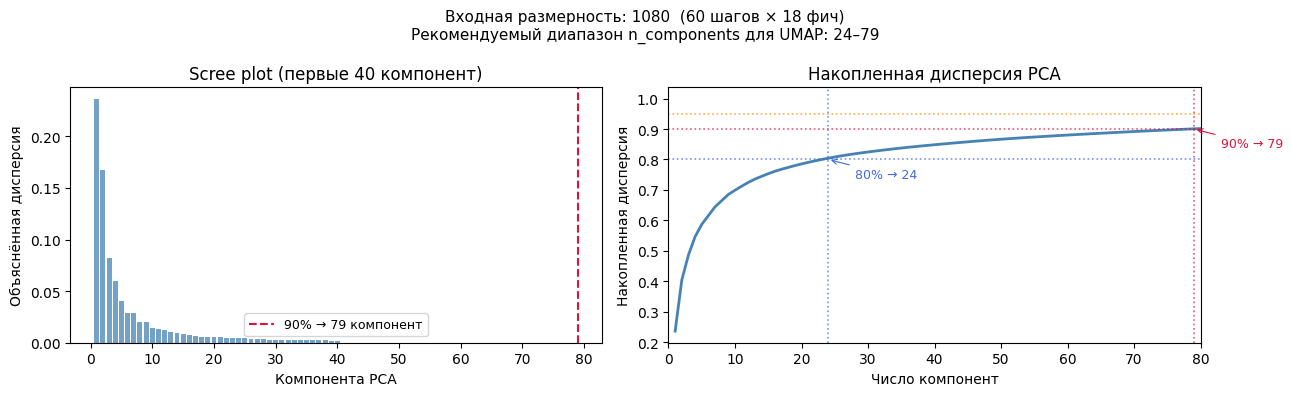


Рекомендуемый диапазон: 24–79 компонент
→ N_COMPONENTS = 79  (порог 90% PCA-дисперсии)


In [4]:
# ── Выбор числа компонент UMAP ────────────────────────────────────────────────
#
# UMAP не имеет явной «объяснённой дисперсии», поэтому используем PCA
# как быстрый прокси intrinsic dimensionality того же пространства F_train_sc.
#
# Логика выбора n_components для кластеризационного UMAP:
#   1. Нужно покрыть ≥ 90% дисперсии → достаточно структуры для HDBSCAN.
#   2. Не брать слишком много (> 20): Euclidean-расстояния деградируют
#      в высоких размерностях (curse of dimensionality), а HDBSCAN именно
#      на них строит граф плотности.
#   3. Не брать слишком мало (< 5): UMAP слишком сильно сжимает → кластеры
#      сливаются в 2D/3D-проекции.

from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(F_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

thresholds = {0.80: "royalblue", 0.90: "crimson", 0.95: "darkorange"}
k_vals = {t: int(np.searchsorted(cum_var, t) + 1) for t in thresholds}

print("PCA: минимальное число компонент для покрытия дисперсии:")
for t, k in k_vals.items():
    print(f"  {int(t*100):>3}%  →  {k:>3} компонент")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, 41), pca_full.explained_variance_ratio_[:40],
            color="steelblue", alpha=0.75, width=0.8)
axes[0].set_xlabel("Компонента PCA")
axes[0].set_ylabel("Объяснённая дисперсия")
axes[0].set_title("Scree plot (первые 40 компонент)")
axes[0].axvline(k_vals[0.90], color="crimson", ls="--", lw=1.5,
                label=f"90% → {k_vals[0.90]} компонент")
axes[0].legend(fontsize=9)

# Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var, lw=2, color="steelblue")
for t, color in thresholds.items():
    k = k_vals[t]
    axes[1].axhline(t, color=color, ls=":", lw=1.2, alpha=0.7)
    axes[1].axvline(k, color=color, ls=":", lw=1.2, alpha=0.7)
    axes[1].annotate(f"{int(t*100)}% → {k}",
                     xy=(k, t), xytext=(k + 4, t - 0.06),
                     fontsize=9, color=color,
                     arrowprops=dict(arrowstyle="->", color=color, lw=0.8))
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная дисперсия")
axes[1].set_title("Накопленная дисперсия PCA")
axes[1].set_xlim(0, 80)

plt.suptitle(
    f"Входная размерность: {F_train_sc.shape[1]}  "
    f"({WINDOW} шагов × {len(FEATURE_COLS)} фич)\n"
    f"Рекомендуемый диапазон n_components для UMAP: {k_vals[0.80]}–{k_vals[0.90]}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── Выбор N_COMPONENTS ───────────────────────────────────────────────────────
# Берём порог 90%: достаточно структуры, но не слишком много для HDBSCAN.
# При необходимости скорректируй вручную (рекомендуемый диапазон ниже).
N_COMPONENTS = k_vals[0.90]

print(f"\nРекомендуемый диапазон: {k_vals[0.80]}–{k_vals[0.90]} компонент")
print(f"→ N_COMPONENTS = {N_COMPONENTS}  (порог 90% PCA-дисперсии)")

In [5]:
# ── PCA → UMAP ────────────────────────────────────────────────────────────────
#
# Пайплайн:  F (360D)  →  PCA (N_COMPONENTS D)  →  UMAP (10D / 2D)
#
# Зачем PCA перед UMAP:
#   • убирает шумовые направления с малой дисперсией (их много в 360D)
#   • UMAP строит граф ближайших соседей — в ~15D это точнее, чем в 360D
#   • заметно ускоряет UMAP (O(N · d · n_neighbors))
#
# UMAP при этом не заменяется PCA — он по-прежнему находит
# нелинейную структуру, но уже в очищенном пространстве.

from sklearn.decomposition import PCA as _PCA

# Шаг 1: PCA — линейное шумоподавление
pca_pre = _PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
P_train = pca_pre.fit_transform(F_train_sc)
P_val   = pca_pre.transform(F_val_sc)
P_test  = pca_pre.transform(F_test_sc)
print(f"PCA:  {F_train_sc.shape}  →  {P_train.shape}")

# Шаг 2: UMAP — нелинейное сжатие для кластеризации
UMAP_CLUST_DIM = min(10, N_COMPONENTS)   # не больше, чем вышло из PCA
umap_clust = UMAPProjector(
    n_components=UMAP_CLUST_DIM, n_neighbors=20, min_dist=0.0,
    metric="euclidean", scale=False, random_state=RANDOM_STATE,
)
Z_train = umap_clust.fit_transform(P_train)
Z_val   = umap_clust.transform(P_val)
Z_test  = umap_clust.transform(P_test)

# Шаг 3: отдельный UMAP 2D — только для визуализации
umap_vis = UMAPProjector(
    n_components=2, n_neighbors=20, min_dist=0.1,
    metric="euclidean", scale=False, random_state=RANDOM_STATE,
)
Z2_train = umap_vis.fit_transform(P_train)

print(f"UMAP {UMAP_CLUST_DIM}D (кластеризация): {Z_train.shape}")
print(f"UMAP  2D (визуализация):  {Z2_train.shape}")

PCA:  (114378, 1080)  →  (114378, 79)
UMAP 10D (кластеризация): (114378, 10)
UMAP  2D (визуализация):  (114378, 2)


In [6]:
# ── Перебор параметров HDBSCAN ────────────────────────────────────────────────
#
# Критерии отбора хорошей конфигурации:
#   ✓  шум ≤ 15 %
#   ✓  кластеров ≥ 2  (не сваливаем всё в один)
#
# Параметры перебора:
#   min_cluster_size — основной регулятор: больше → меньше кластеров и шума,
#                      но крупнее и «ровнее» кластеры.
#   min_samples      — строгость плотности ядра: больше → больше шума.
#   cluster_selection_method:
#       'eom'  — Excess of Mass, разрешает кластеры разной плотности (дефолт).
#       'leaf' — листья дерева, много мелких равных кластеров.
#
# cluster_selection_epsilon не включаем в grid: он искусственно сливает
# соседние кластеры по расстоянию — это лучше делать вручную после анализа.

import time, importlib, sys
from itertools import product
from sklearn.metrics import silhouette_score as _sil_score

# Принудительно перегружаем модуль, чтобы подхватить изменения без перезапуска ядра
import clustering.hdbscan as _hdb_mod
importlib.reload(_hdb_mod)
from clustering.hdbscan import HDBSCANClusterer

MIN_CLUSTER_SIZE_GRID = [200, 500, 1000, 2000, 3000]
MIN_SAMPLES_GRID      = [5, 15, 50]
METHOD_GRID           = ["eom", "leaf"]
SIL_SAMPLE            = 20_000          # сэмпл для Silhouette (O(n²))
NOISE_LIMIT           = 15.0            # %
MIN_CLUSTERS          = 2

configs = list(product(MIN_CLUSTER_SIZE_GRID, MIN_SAMPLES_GRID, METHOD_GRID))
print(f"Конфигураций: {len(configs)}.  Запускаем…\n")

rows = []
for i, (mcs, ms, method) in enumerate(configs, 1):
    t0 = time.time()
    h = HDBSCANClusterer(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_method=method,
        scale=False,
        prediction_data=False,   # не нужен для sweep — экономим память
    )
    h.fit(Z_train)
    elapsed = time.time() - t0

    lbl   = h.labels_
    n_c   = h.n_clusters_
    noise = h.noise_ratio_ * 100
    ok    = (noise <= NOISE_LIMIT) and (n_c >= MIN_CLUSTERS)

    # Silhouette для любой конфигурации с ≥ 2 кластерами (шум исключаем из расчёта)
    sil = float("nan")
    if n_c >= MIN_CLUSTERS:
        mask   = lbl != -1
        y_valid = lbl[mask]
        if len(np.unique(y_valid)) >= 2:
            n_samp = min(SIL_SAMPLE, int(mask.sum()))
            sil    = round(_sil_score(Z_train[mask], y_valid,
                                       sample_size=n_samp, random_state=42), 4)

    rows.append({
        "min_cluster_size": mcs,
        "min_samples":      ms,
        "method":           method,
        "n_clusters":       n_c,
        "noise_%":          round(noise, 1),
        "silhouette":       sil,
        "_ok":              ok,
        "time_s":           round(elapsed, 1),
    })
    flag = "✓" if ok else " "
    print(f"[{i:02d}/{len(configs)}] {flag}  "
          f"mcs={mcs:5d}  ms={ms:2d}  {method:<4}  "
          f"→ {n_c:2d} cls  noise={noise:5.1f}%  "
          f"sil={sil:.4f}  ({elapsed:.1f}s)")

# ── Итоговая таблица ──────────────────────────────────────────────────────────
df_sweep = pd.DataFrame(rows)
noise_ok = df_sweep["noise_%"] <= NOISE_LIMIT
clust_ok = df_sweep["n_clusters"] >= MIN_CLUSTERS
good     = (noise_ok & clust_ok).values

print(f"\n{'═'*72}")
print(f"Конфигов с noise ≤ {NOISE_LIMIT}%: {noise_ok.sum()} из {len(configs)}")
print(f"Конфигов с n_clusters ≥ {MIN_CLUSTERS}: {clust_ok.sum()} из {len(configs)}")
print(f"Прошли оба фильтра: {good.sum()}")

def _row_style(row):
    if good[row.name]:
        return ["background-color: #d4edda"] * len(row)   # зелёный — оба фильтра
    if clust_ok[row.name]:
        return ["background-color: #fff3cd"] * len(row)   # жёлтый — только кластеры, шум высокий
    return [""] * len(row)

print("\n— Полная таблица (жёлтый = ≥2 кластеров, но шум > 15%; зелёный = оба условия) —")
display(
    df_sweep.drop(columns="_ok")
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
    .style
    .apply(_row_style, axis=1)
    .format({"noise_%": "{:.1f}", "silhouette": "{:.4f}", "time_s": "{:.1f}"})
)

Конфигураций: 30.  Запускаем…

[01/30]    mcs=  200  ms= 5  eom   →  2 cls  noise= 49.3%  sil=-0.1150  (6.6s)
[02/30]    mcs=  200  ms= 5  leaf  → 35 cls  noise= 88.9%  sil=0.4195  (5.0s)
[03/30]    mcs=  200  ms=15  eom   →  2 cls  noise= 46.6%  sil=-0.1091  (4.8s)
[04/30]    mcs=  200  ms=15  leaf  → 22 cls  noise= 91.5%  sil=0.4502  (4.7s)
[05/30]    mcs=  200  ms=50  eom   →  8 cls  noise= 73.0%  sil=-0.0331  (4.7s)
[06/30]    mcs=  200  ms=50  leaf  → 15 cls  noise= 89.4%  sil=0.4361  (4.9s)
[07/30]    mcs=  500  ms= 5  eom   →  2 cls  noise= 63.0%  sil=-0.0336  (5.1s)
[08/30]    mcs=  500  ms= 5  leaf  → 12 cls  noise= 88.9%  sil=0.4447  (5.1s)
[09/30]    mcs=  500  ms=15  eom   →  2 cls  noise= 68.3%  sil=-0.0359  (4.7s)
[10/30]    mcs=  500  ms=15  leaf  →  8 cls  noise= 92.5%  sil=0.4771  (4.8s)
[11/30]    mcs=  500  ms=50  eom   →  5 cls  noise= 73.9%  sil=0.2554  (4.7s)
[12/30]    mcs=  500  ms=50  leaf  →  9 cls  noise= 90.1%  sil=0.4812  (4.7s)
[13/30]    mcs= 1000  ms= 5 

,min_cluster_size,min_samples,method,n_clusters,noise_%,silhouette,time_s
0,2000,15,leaf,2,85.6,0.4947,5.1
1,2000,15,eom,2,85.6,0.4947,5.1
2,3000,15,leaf,2,85.6,0.4947,5.0
3,3000,15,eom,2,85.6,0.4947,4.7
4,500,50,leaf,9,90.1,0.4812,4.7
5,500,15,leaf,8,92.5,0.4771,4.8
6,3000,50,leaf,2,74.2,0.4688,4.7
7,3000,50,eom,2,74.2,0.4688,4.9
8,200,15,leaf,22,91.5,0.4502,4.7
9,500,5,leaf,12,88.9,0.4447,5.1


In [7]:
# ── Финальный HDBSCAN ─────────────────────────────────────────────────────────
# Автоматически берём конфигурацию с наибольшим Silhouette из перебора выше.
# Если хочешь выбрать вручную — замени строку best = ... на нужные параметры.

# Берём лучший по silhouette среди конфигов с ≥ 2 кластерами.
# Если есть конфиги с noise ≤ 15% — предпочитаем их; иначе берём лучший из остальных.
candidates = df_sweep[(df_sweep["n_clusters"] >= MIN_CLUSTERS) & df_sweep["silhouette"].notna()]
good_candidates = candidates[candidates["noise_%"] <= NOISE_LIMIT]
best = (good_candidates if len(good_candidates) else candidates).sort_values("silhouette", ascending=False).iloc[0]
print("Выбранная конфигурация:")
print(best[["min_cluster_size", "min_samples", "method", "n_clusters", "noise_%", "silhouette"]].to_string())

hdb = HDBSCANClusterer(
    min_cluster_size=int(best["min_cluster_size"]),
    min_samples=int(best["min_samples"]),
    cluster_selection_method=str(best["method"]),
    scale=False,
    prediction_data=True,
)
hdb.fit(Z_train)

labels_train = hdb.labels_
n_clusters   = hdb.n_clusters_
noise_pct    = hdb.noise_ratio_ * 100
print(f"\nКластеров: {n_clusters}  |  Шум: {noise_pct:.1f}%")

labels_val  = hdb.predict(Z_val)
labels_test = hdb.predict(Z_test)

for c in range(n_clusters):
    print(f"  C{c}: {(labels_train == c).sum():,} окон")

Выбранная конфигурация:
min_cluster_size      2000
min_samples             15
method                leaf
n_clusters               2
noise_%               85.6
silhouette          0.4947

Кластеров: 2  |  Шум: 85.6%
  C0: 5,030 окон
  C1: 11,451 окон


In [8]:
# ── Сборка tickers_train / timestamps_train ───────────────────────────────────
# Порядок итерации по dataset.items() совпадает с concat_splits,
# поэтому массивы выровнены с X_train / labels_train.

train_end = loader.split.train_end
tickers_list, ts_list = [], []
for ticker, splits in dataset.items():
    X_t, _ = splits["train"]
    n_w = len(X_t)
    for i in range(n_w):
        days_back = (n_w - 1 - i) * STRIDE
        w_end = train_end - pd.Timedelta(days=int(days_back * 1.4))
        tickers_list.append(ticker)
        ts_list.append(w_end)

tickers_train    = np.array(tickers_list)
timestamps_train = np.array(ts_list)

# ── Медианы признаков (нужны ниже для RegimeInterpreter) ─────────────────────
CLOSE_IDX = FEATURE_COLS.index("close")
feat_df   = pd.DataFrame(X_train[:, -1, :], columns=FEATURE_COLS)
feat_df["cluster"] = labels_train
medians   = feat_df[feat_df["cluster"] != -1].groupby("cluster")[FEATURE_COLS].median()

# ── ClusterAnalyzer ───────────────────────────────────────────────────────────
analyzer = ClusterAnalyzer(
    labels=labels_train,
    windows=X_train,
    embeddings=Z_train,
    timestamps=timestamps_train,
    tickers=tickers_train,
    close_idx=CLOSE_IDX,
    feature_names=FEATURE_COLS,
)

In [9]:
# ── Метрики качества кластеризации ───────────────────────────────────────────
# X_metrics=Z_train — исходное 10D-пространство UMAP, на котором обучался HDBSCAN.
# Шумовые точки (label == -1) автоматически исключаются.
display(analyzer.cluster_metrics(X=Z_train))

,value,interpretation,note
metric,,,
Silhouette Score,0.4947,↑ лучше (−1 … +1),"n=16,481"
Davies-Bouldin Index,0.7597,↓ лучше (≥ 0),"n=16,481"
Calinski-Harabasz Index,18908.3900,↑ лучше (≥ 0),"n=16,481"
Noise ratio,85.5900,↓ лучше (%),"97,897 / 114,378 точек"
N clusters,2.0000,—,без шума


══════════════════════════════════════════════════════════
  ClusterAnalyzer
  2 кластеров · 16,481 валидных окон · 97,897 шум
══════════════════════════════════════════════════════════

── Метрики качества кластеризации ──────────────────────


,value,interpretation,note
metric,,,
Silhouette Score,0.4947,↑ лучше (−1 … +1),"n=16,481"
Davies-Bouldin Index,0.7597,↓ лучше (≥ 0),"n=16,481"
Calinski-Harabasz Index,18908.3900,↑ лучше (≥ 0),"n=16,481"
Noise ratio,85.5900,↓ лучше (%),"97,897 / 114,378 точек"
N clusters,2.0000,—,без шума



[1/7] 2D scatter эмбеддингов…
[2/7] Средние профили окон…
[3/7] Статистики кластеров…
[4/7] Тепловая карта признаков…
[5/7] Распределение returns…
[6/7] Временное распределение…
[7/7] Матрица переходов…

══════════════════════════════════════════════════════════
  Готово. Фигуры доступны в возвращённом словаре.
══════════════════════════════════════════════════════════


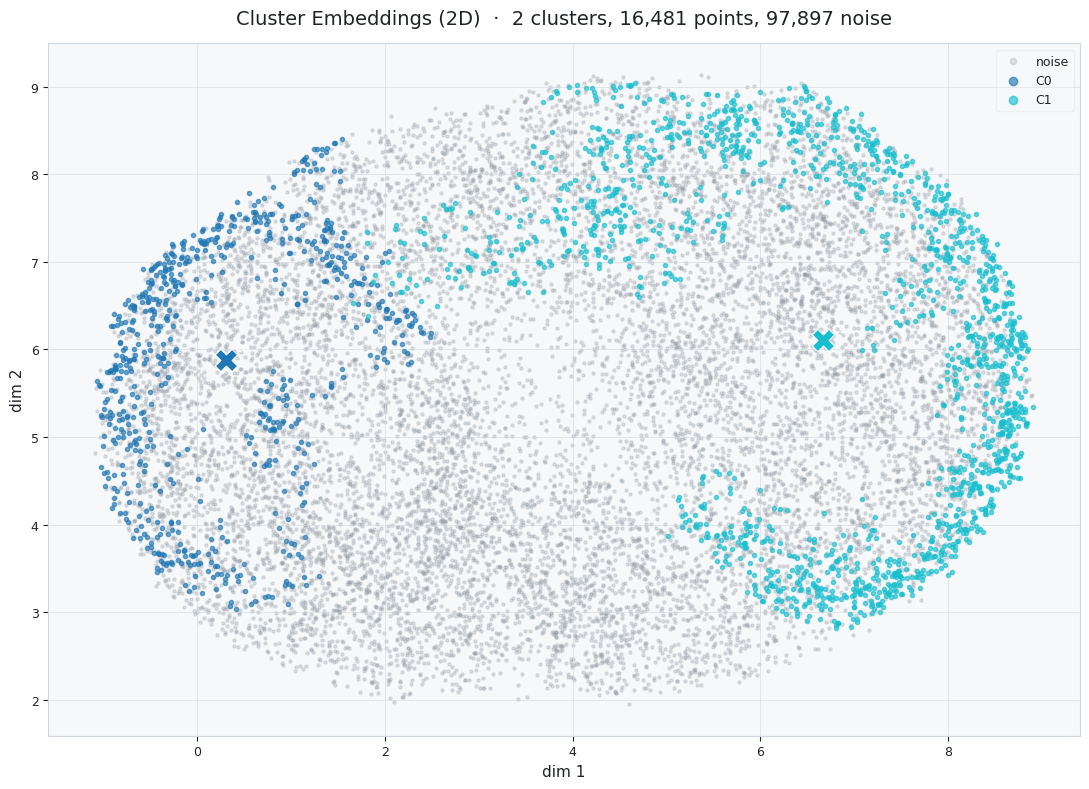

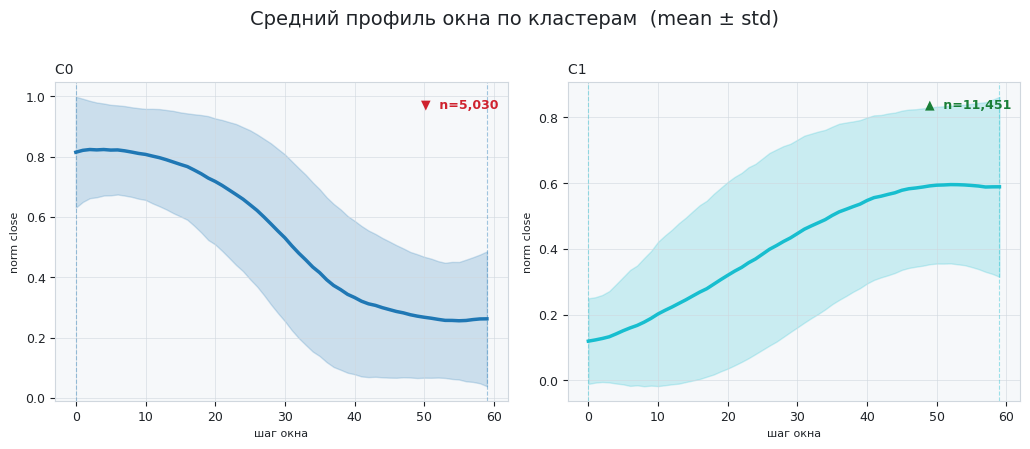

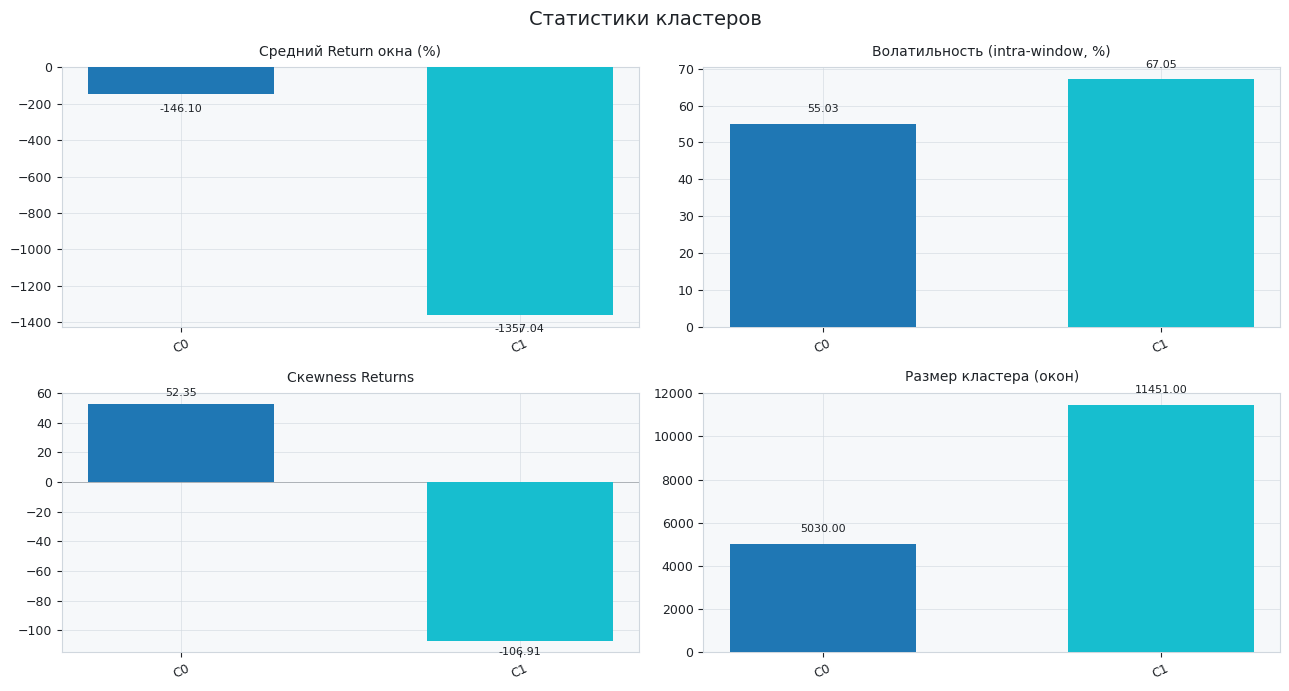

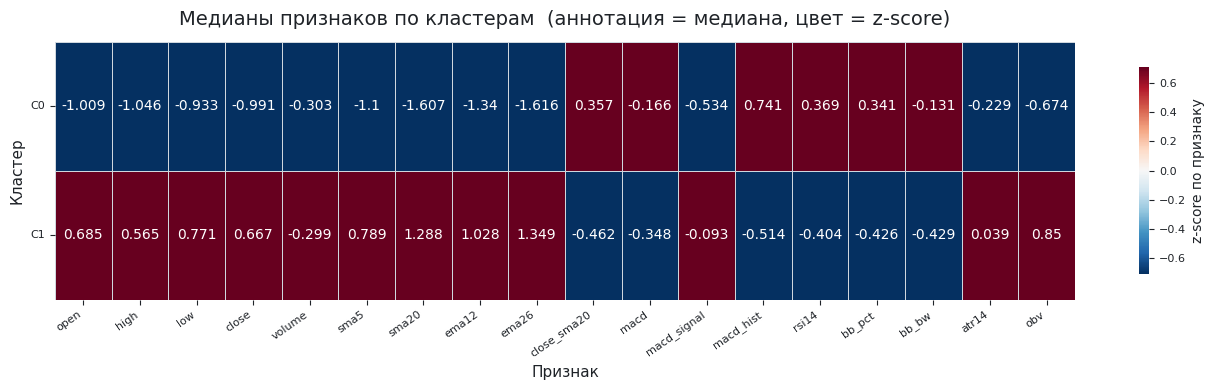

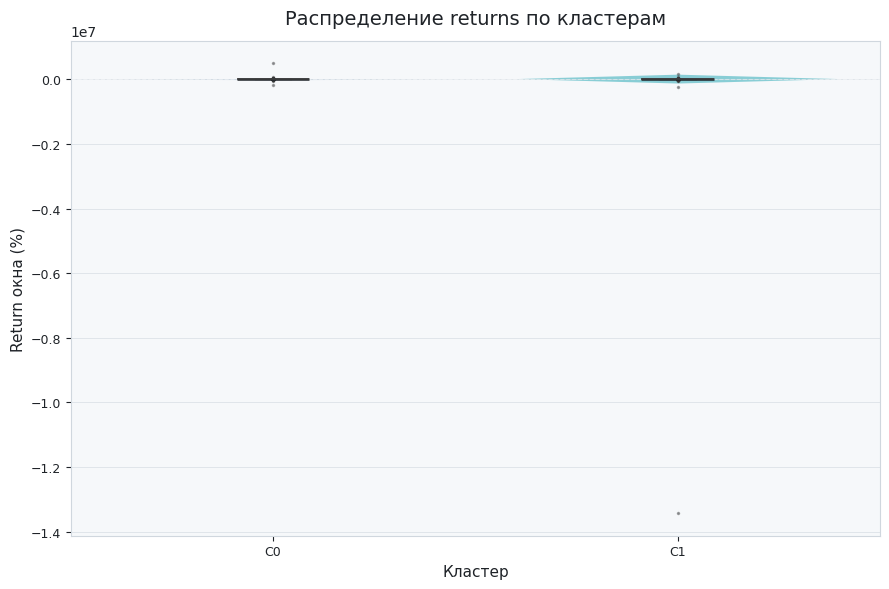

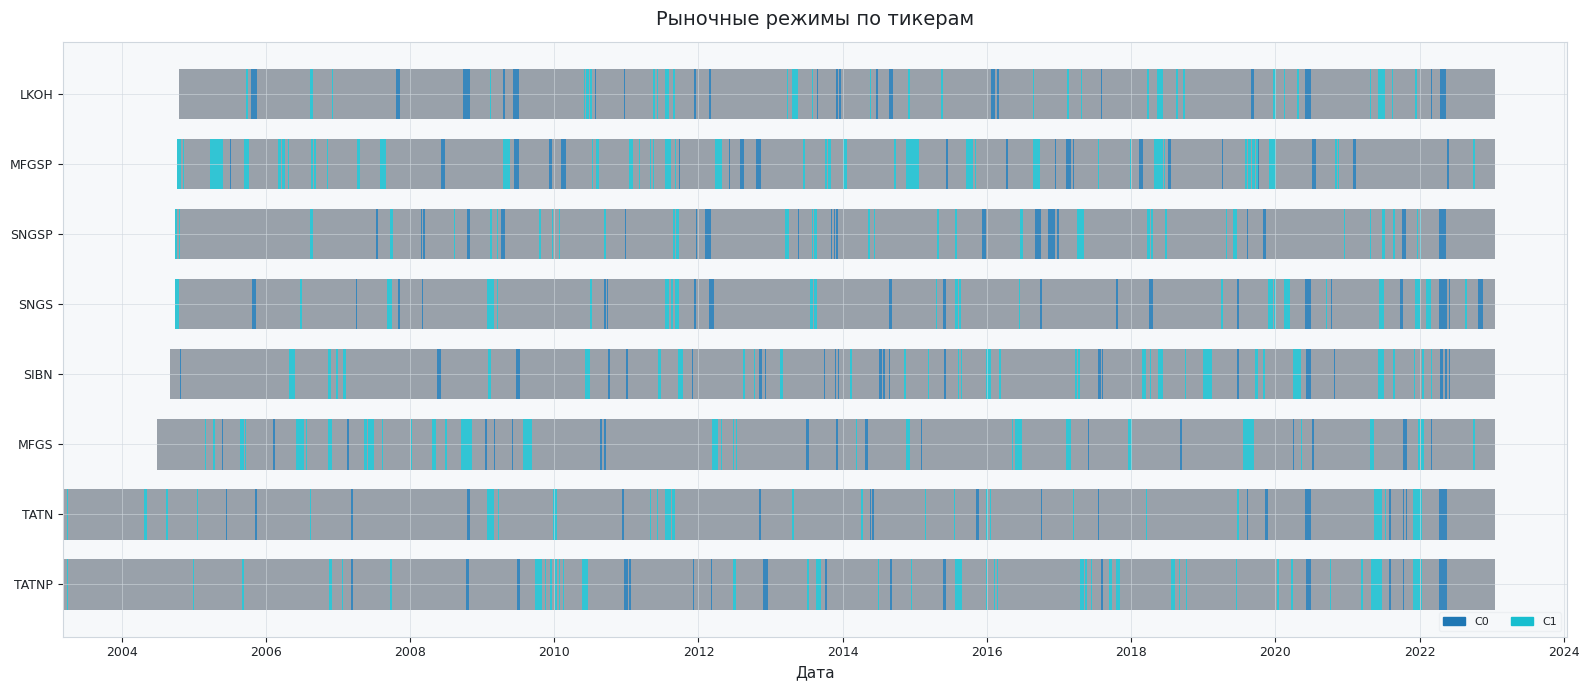

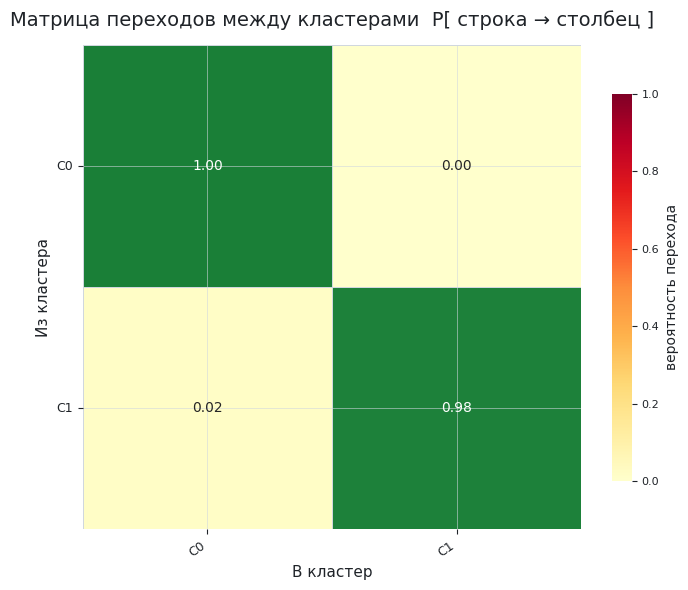

In [10]:
# ── Все визуализации через ClusterAnalyzer ────────────────────────────────────
figs = analyzer.run_all(embeddings_2d=Z2_train, X_metrics=Z_train, aggregate_temporal=False)
plt.show()

In [11]:
# Медианы признаков (для RegimeInterpreter в cell 9)
print("Медианы признаков по кластерам:")
print(medians[FEATURE_COLS].round(4).to_string())

Медианы признаков по кластерам:
           open    high     low   close  volume    sma5   sma20   ema12   ema26  close_sma20    macd  macd_signal  macd_hist   rsi14  bb_pct   bb_bw   atr14     obv
cluster                                                                                                                                                             
0       -1.0092 -1.0463 -0.9330 -0.9915 -0.3028 -1.1001 -1.6069 -1.3396 -1.6156       0.3575 -0.1663      -0.5344     0.7405  0.3688  0.3408 -0.1308 -0.2292 -0.6742
1        0.6845  0.5653  0.7711  0.6672 -0.2990  0.7894  1.2878  1.0282  1.3491      -0.4622 -0.3482      -0.0925    -0.5140 -0.4041 -0.4258 -0.4288  0.0393  0.8502


In [12]:
# Чтобы задать имена кластеров вручную после изучения тепловой карты признаков,
# передайте cluster_names при создании analyzer или обновите постфактум:
#
# analyzer._custom_names = {0: "Uptrend", 1: "Panic", 2: "Sideways", ...}
#
# После этого вызовите нужный plot-метод повторно, например:
# analyzer.plot_embeddings_2d(embeddings_2d=Z2_train)